# Automated Trading System — Data Analysis & ML Development

This notebook documents the development process of our ETL pipeline and Machine Learning model.
We use this notebook for exploration, then the final code lives in `src/etl.py` and `src/model.py`.

**Companies:** AAPL, MSFT, GOOG, AMZN, TSLA

---

## 1. Setup & Imports

In [ ]:
import sys
import os
import joblib
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Use trading-system/src as the single source of truth for ETL.
# The web app also imports from this same location, so both pipelines
# always share identical feature engineering code.
sys.path.insert(0, 'trading-system/src')
from etl import FEATURE_COLUMNS, transform

warnings.filterwarnings('ignore')

TICKERS = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
DATA_DIR     = 'data'
PROCESSED_DIR = 'data/processed'
MODELS_DIR    = 'models'

print('Libraries loaded successfully!')

## 2. Data Extraction (ETL — Extract)

We load the raw CSV files downloaded from SimFin's bulk download.
SimFin uses semicolons (`;`) as delimiters.

In [2]:
# Load raw data from SimFin bulk download
prices_df    = pd.read_csv(os.path.join(DATA_DIR, 'us-shareprices-daily.csv'), sep=';')
companies_df = pd.read_csv(os.path.join(DATA_DIR, 'us-companies.csv'), sep=';')

print(f'Share prices: {prices_df.shape[0]:,} rows, {prices_df.shape[1]} columns')
print(f'Companies:    {companies_df.shape[0]:,} rows')
print(f'\nShare prices columns: {list(prices_df.columns)}')

Share prices: 6,210,533 rows, 11 columns
Companies:    6,532 rows

Share prices columns: ['Ticker', 'SimFinId', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume', 'Dividend', 'Shares Outstanding']


In [3]:
# Preview the raw data
prices_df.head()

,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
0,A,45846,2020-04-20,79.05,79.05,76.98,77.37,74.38,1679446,NaN,309651359.0
1,A,45846,2020-04-21,75.76,75.80,73.71,73.75,70.90,2824291,NaN,309651359.0
2,A,45846,2020-04-22,74.75,75.58,73.78,75.17,72.27,2347360,NaN,309651359.0
3,A,45846,2020-04-23,76.60,77.49,75.05,75.09,72.19,2097688,NaN,309651359.0
4,A,45846,2020-04-24,75.62,75.91,74.02,75.75,72.82,1654283,NaN,309651359.0


In [4]:
# Confirm all 5 tickers are present in the dataset
for t in TICKERS:
    count = len(prices_df[prices_df['Ticker'] == t])
    print(f'{t}: {count:,} rows')

AAPL: 1,238 rows
MSFT: 1,238 rows
GOOG: 1,238 rows
AMZN: 1,238 rows
TSLA: 1,238 rows


## 3. Data Transformation (ETL — Transform)

We develop the pipeline step-by-step for **AAPL only** first.
Once we verify it works, section 3.7 runs it for all 5 tickers automatically.

In [5]:
# Filter for AAPL — used for exploration in sections 3.1 to 3.5
ticker = 'AAPL'
df = prices_df[prices_df['Ticker'] == ticker].copy()
print(f'Filtered {len(df):,} rows for {ticker}')

company_info = companies_df[companies_df['Ticker'] == ticker]
print(f'Company: {company_info.iloc[0]["Company Name"]}')

Filtered 1,238 rows for AAPL
Company: APPLE INC


### 3.1 Cleaning

In [6]:
# Parse dates and sort
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Drop rows with missing Close price — unusable without a price
df = df.dropna(subset=['Close'])

# Fill missing Volume with 0 (SimFin free tier omits Volume for some dates)
if 'Volume' in df.columns:
    df['Volume'] = df['Volume'].fillna(0)

# Use Close as a fallback when High/Low are missing
if 'High' in df.columns:
    df['High'] = df['High'].fillna(df['Close'])
if 'Low' in df.columns:
    df['Low'] = df['Low'].fillna(df['Close'])

# Remove duplicate dates (keep the last entry)
df = df.drop_duplicates(subset=['Date'], keep='last').reset_index(drop=True)

print(f'\nCleaned data: {len(df):,} rows')
df.head()

Missing values per column:
Ticker                   0
SimFinId                 0
Date                     0
Open                     0
High                     0
Low                      0
Close                    0
Adj. Close               0
Volume                   0
Dividend              1218
Shares Outstanding       0
dtype: int64

Cleaned data: 1,238 rows


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
0,AAPL,111052,2020-04-20,69.49,70.42,69.21,69.23,66.92,130015000,NaN,1.733734e+10
1,AAPL,111052,2020-04-21,69.07,69.31,66.36,67.09,64.85,180991572,NaN,1.733734e+10
2,AAPL,111052,2020-04-22,68.40,69.47,68.05,69.03,66.72,117057368,NaN,1.733734e+10
3,AAPL,111052,2020-04-23,68.97,70.44,68.72,68.76,66.46,124814328,NaN,1.733734e+10
4,AAPL,111052,2020-04-24,69.30,70.75,69.25,70.74,68.38,126508732,NaN,1.733734e+10


### 3.2 Feature Engineering

We create **technical indicators** that the ML model will use as input features:
- **Returns**: Daily percentage change in price
- **SMA_5, SMA_20**: Simple Moving Averages (short/medium term trends)
- **EMA_12**: Exponential Moving Average (weights recent prices more)
- **RSI_14**: Relative Strength Index (momentum — overbought/oversold)
- **Volatility_20**: Rolling standard deviation of returns
- **Volume_Change**: Daily change in trading volume
- **High_Low_Range**: Intraday price range

In [7]:
# Daily Returns
df['Returns'] = df['Close'].pct_change()

# Simple Moving Averages
df['SMA_5']  = df['Close'].rolling(window=5).mean()
df['SMA_20'] = df['Close'].rolling(window=20).mean()

# Exponential Moving Average
df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()

# RSI (Relative Strength Index)
delta    = df['Close'].diff()
gain     = delta.where(delta > 0, 0.0)
loss     = (-delta).where(delta < 0, 0.0)
avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()
rs = avg_gain / avg_loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Volatility
df['Volatility_20'] = df['Returns'].rolling(window=20).std()

# Volume Change
if 'Volume' in df.columns and df['Volume'].sum() > 0:
    df['Volume_Change'] = df['Volume'].pct_change().replace([np.inf, -np.inf], 0).fillna(0)
else:
    df['Volume_Change'] = 0.0

# High-Low Range
df['High_Low_Range'] = df['High'] - df['Low']

print('Features created!')
df[['Date', 'Close', 'Returns', 'SMA_5', 'SMA_20', 'RSI_14', 'Volatility_20']].tail(10)

Features created!


,Date,Close,Returns,SMA_5,SMA_20,RSI_14,Volatility_20
1228,2025-03-10,227.48,-0.048480,234.710,239.4605,28.422657,0.017183
1229,2025-03-11,220.84,-0.029189,231.692,239.1200,23.657093,0.018390
1230,2025-03-12,216.98,-0.017479,227.940,238.3380,20.263863,0.017875
1231,2025-03-13,209.68,-0.033644,222.810,236.9785,17.702143,0.018338
1232,2025-03-14,213.49,0.018171,217.694,235.5765,20.920574,0.018230
1233,2025-03-17,214.00,0.002389,214.998,234.0465,21.634615,0.017815
1234,2025-03-18,212.69,-0.006121,213.368,232.4575,23.832041,0.017760
1235,2025-03-19,215.24,0.011989,213.020,230.9760,28.934301,0.018164
1236,2025-03-20,214.10,-0.005296,213.904,229.3895,21.670752,0.018008
1237,2025-03-21,218.27,0.019477,214.860,228.0255,29.967559,0.018913


### 3.3 Visualize the Data (AAPL — Exploratory Preview)

This chart is for AAPL only and uses the `df` variable set in section 3.1.

**Important:** do not re-run this cell after section 3.7, because by then the loop
variable `ticker` will be `'TSLA'` (last in the list) and the title will be misleading.
For a chart of all 5 tickers, see **section 3.8**.

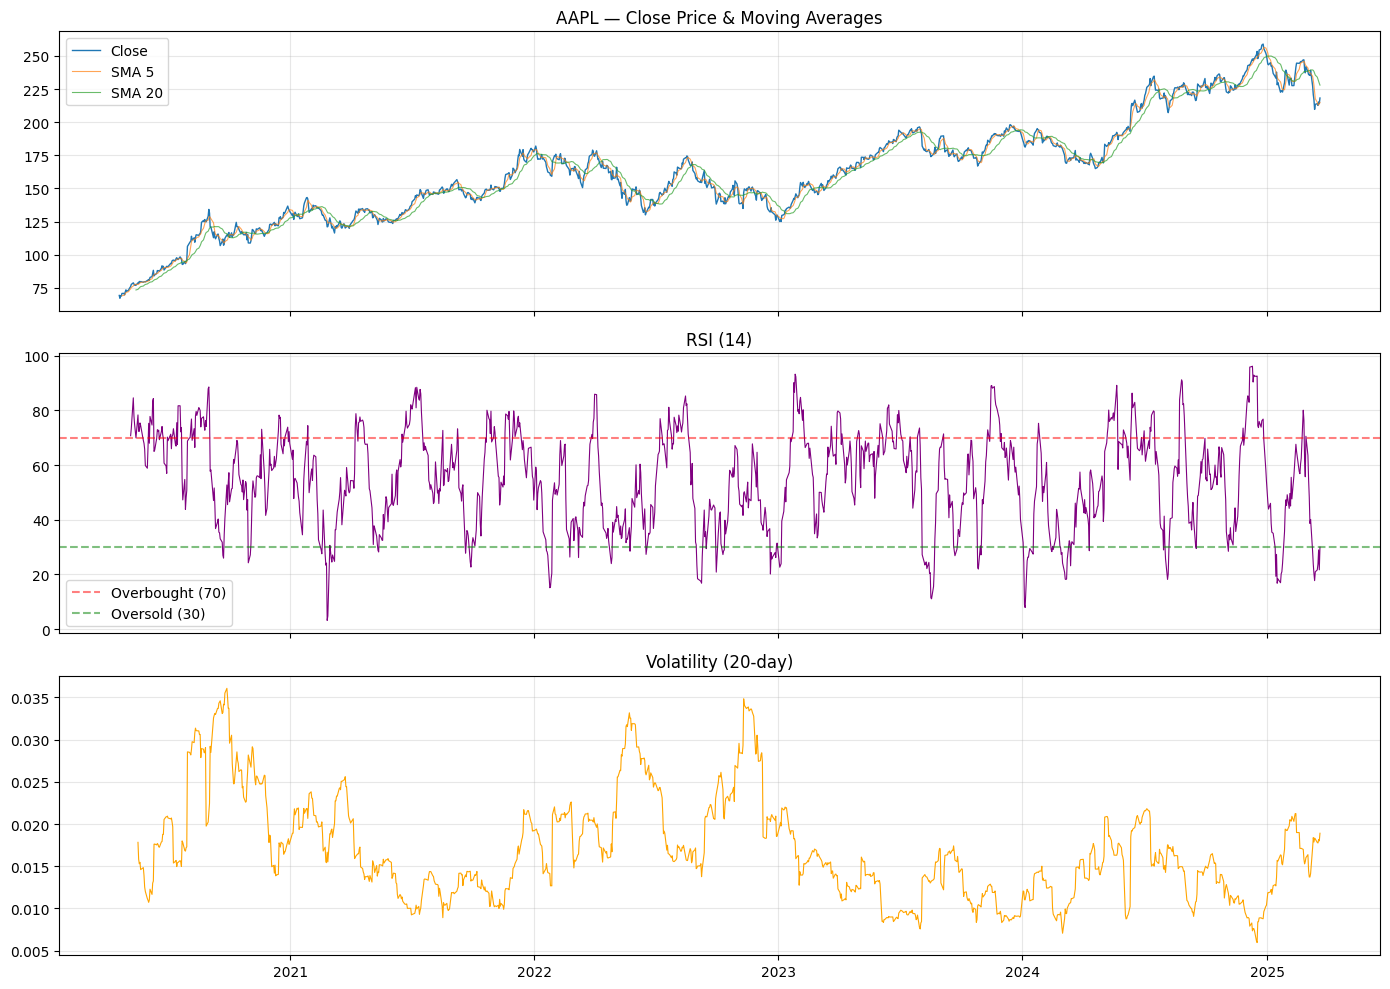

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Close price + moving averages
axes[0].plot(df['Date'], df['Close'],  label='Close', linewidth=1)
axes[0].plot(df['Date'], df['SMA_5'],  label='SMA 5',  linewidth=0.8, alpha=0.7)
axes[0].plot(df['Date'], df['SMA_20'], label='SMA 20', linewidth=0.8, alpha=0.7)
axes[0].set_title(f'AAPL — Close Price & Moving Averages')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RSI
axes[1].plot(df['Date'], df['RSI_14'], color='purple', linewidth=0.8)
axes[1].axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought (70)')
axes[1].axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold (30)')
axes[1].set_title('RSI (14)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Volatility
axes[2].plot(df['Date'], df['Volatility_20'], color='orange', linewidth=0.8)
axes[2].set_title('Volatility (20-day)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.4 Create Target Variable

Our target is **binary classification**:
- `1` = tomorrow's Close price is **higher** than today's (UP)
- `0` = tomorrow's Close price is **lower or equal** to today's (DOWN)

In [9]:
# 1 if next day's Close > today's Close, else 0
df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

print('Target distribution:')
print(df['Target'].value_counts())
print(f'\nUp days:   {df["Target"].sum()} ({df["Target"].mean()*100:.1f}%)')
print(f'Down days: {(df["Target"] == 0).sum()} ({(1-df["Target"].mean())*100:.1f}%)')

Target distribution:
Target
1    659
0    579
Name: count, dtype: int64

Up days:   659 (53.2%)
Down days: 579 (46.8%)


### 3.5 Drop Missing Rows & Save

In [10]:
# FEATURE_COLUMNS is imported from src/etl.py — no need to redefine it here
essential = FEATURE_COLUMNS + ['Target']

rows_before = len(df)
df = df.dropna(subset=essential).reset_index(drop=True)
rows_after = len(df)

print(f'Dropped {rows_before - rows_after} rows with NaN values')
print(f'Final AAPL dataset: {rows_after:,} rows')
df.head()

Dropped 20 rows with NaN values
Final AAPL dataset: 1,218 rows


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding,Returns,SMA_5,SMA_20,EMA_12,RSI_14,Volatility_20,Volume_Change,High_Low_Range,Target
0,AAPL,111052,2020-05-18,78.29,79.12,77.58,78.74,76.31,135372500,NaN,1.733734e+10,0.023528,77.564,73.8290,76.179658,78.331258,0.017834,-0.186211,1.54,0
1,AAPL,111052,2020-05-19,78.76,79.63,78.25,78.28,75.87,101729540,NaN,1.733734e+10,-0.005842,77.650,74.3885,76.502788,72.312017,0.015826,-0.248521,1.38,1
2,AAPL,111052,2020-05-20,79.17,79.88,79.13,79.81,77.35,111504860,NaN,1.733734e+10,0.019545,78.230,74.9275,77.011590,72.331461,0.015300,0.096091,0.75,0
3,AAPL,111052,2020-05-21,79.67,80.22,78.97,79.21,76.77,102688844,NaN,1.733734e+10,-0.007518,78.594,75.4500,77.349807,75.402635,0.015461,-0.079064,1.25,1
4,AAPL,111052,2020-05-22,78.94,79.81,78.84,79.72,77.26,81803016,NaN,1.733734e+10,0.006439,79.152,75.8990,77.714452,74.448669,0.014602,-0.203389,0.97,0


---

## 3.6 Reusable Transform Function

All transformation steps above are packaged into a single `transform()` function in `src/etl.py`.
This is the **single source of truth** for feature engineering — used in two places:
- `src/etl.py` — offline bulk processing on historical data
- The Streamlit web app — applied to fresh API data before prediction

Both must use the same function so the model always receives identically-structured input.

The cell below runs a smoke test to confirm the import and the function work correctly.

In [11]:
# Smoke test — confirm transform() works correctly on AAPL
df_test = transform(prices_df, 'AAPL', include_target=True)
print(f'transform() OK — {len(df_test):,} rows')
print(f'Columns: {list(df_test.columns)}')
df_test.tail(3)

transform() OK — 1,218 rows
Columns: ['Ticker', 'SimFinId', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume', 'Dividend', 'Shares Outstanding', 'Returns', 'SMA_5', 'SMA_20', 'EMA_12', 'RSI_14', 'Volatility_20', 'Volume_Change', 'High_Low_Range', 'Target']


,Ticker,SimFinId,Date,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding,Returns,SMA_5,SMA_20,EMA_12,RSI_14,Volatility_20,Volume_Change,High_Low_Range,Target
1215,AAPL,111052,2025-03-19,214.22,218.76,213.75,215.24,214.32,54385391,NaN,1.502207e+10,0.011989,213.020,230.9760,221.380740,28.934301,0.018164,0.281694,5.01,0
1216,AAPL,111052,2025-03-20,213.99,217.49,212.22,214.10,213.18,48862947,NaN,1.502207e+10,-0.005296,213.904,229.3895,220.260626,21.670752,0.018008,-0.101543,5.27,1
1217,AAPL,111052,2025-03-21,211.56,218.84,211.28,218.27,217.34,94127768,NaN,1.502207e+10,0.019477,214.860,228.0255,219.954376,29.967559,0.018913,0.926363,7.56,0


---

## 3.7 Run ETL for All 5 Tickers

Apply `transform()` to every ticker and save one processed CSV per company to `data/processed/`.
These files are the input to the ML model training in section 4.

In [12]:
os.makedirs(PROCESSED_DIR, exist_ok=True)

etl_results = {}

for t in TICKERS:
    print(f'Processing {t}...', end=' ')
    try:
        df_out = transform(prices_df, t, include_target=True)
        out_path = os.path.join(PROCESSED_DIR, f'{t}_processed.csv')
        df_out.to_csv(out_path, index=False)
        etl_results[t] = {'rows': len(df_out), 'status': 'OK'}
        print(f'{len(df_out):,} rows saved.')
    except Exception as e:
        etl_results[t] = {'rows': 0, 'status': f'ERROR: {e}'}
        print(f'FAILED — {e}')

print('\n--- ETL Summary ---')
print(pd.DataFrame(etl_results).T.to_string())

Processing AAPL... 1,218 rows saved.
Processing MSFT... 1,218 rows saved.
Processing GOOG... 1,218 rows saved.
Processing AMZN... 1,218 rows saved.
Processing TSLA... 1,218 rows saved.

--- ETL Summary ---
      rows status
AAPL  1218     OK
MSFT  1218     OK
GOOG  1218     OK
AMZN  1218     OK
TSLA  1218     OK


---

## 3.8 Visualize All 5 Tickers

Overview chart for all companies. Reads directly from the processed CSVs saved in 3.7
so it never depends on what `ticker` or `df` happen to be in memory.

Each row = one company. Columns: price + moving averages | RSI | volatility.

**Run section 3.7 first** so the processed CSVs exist.

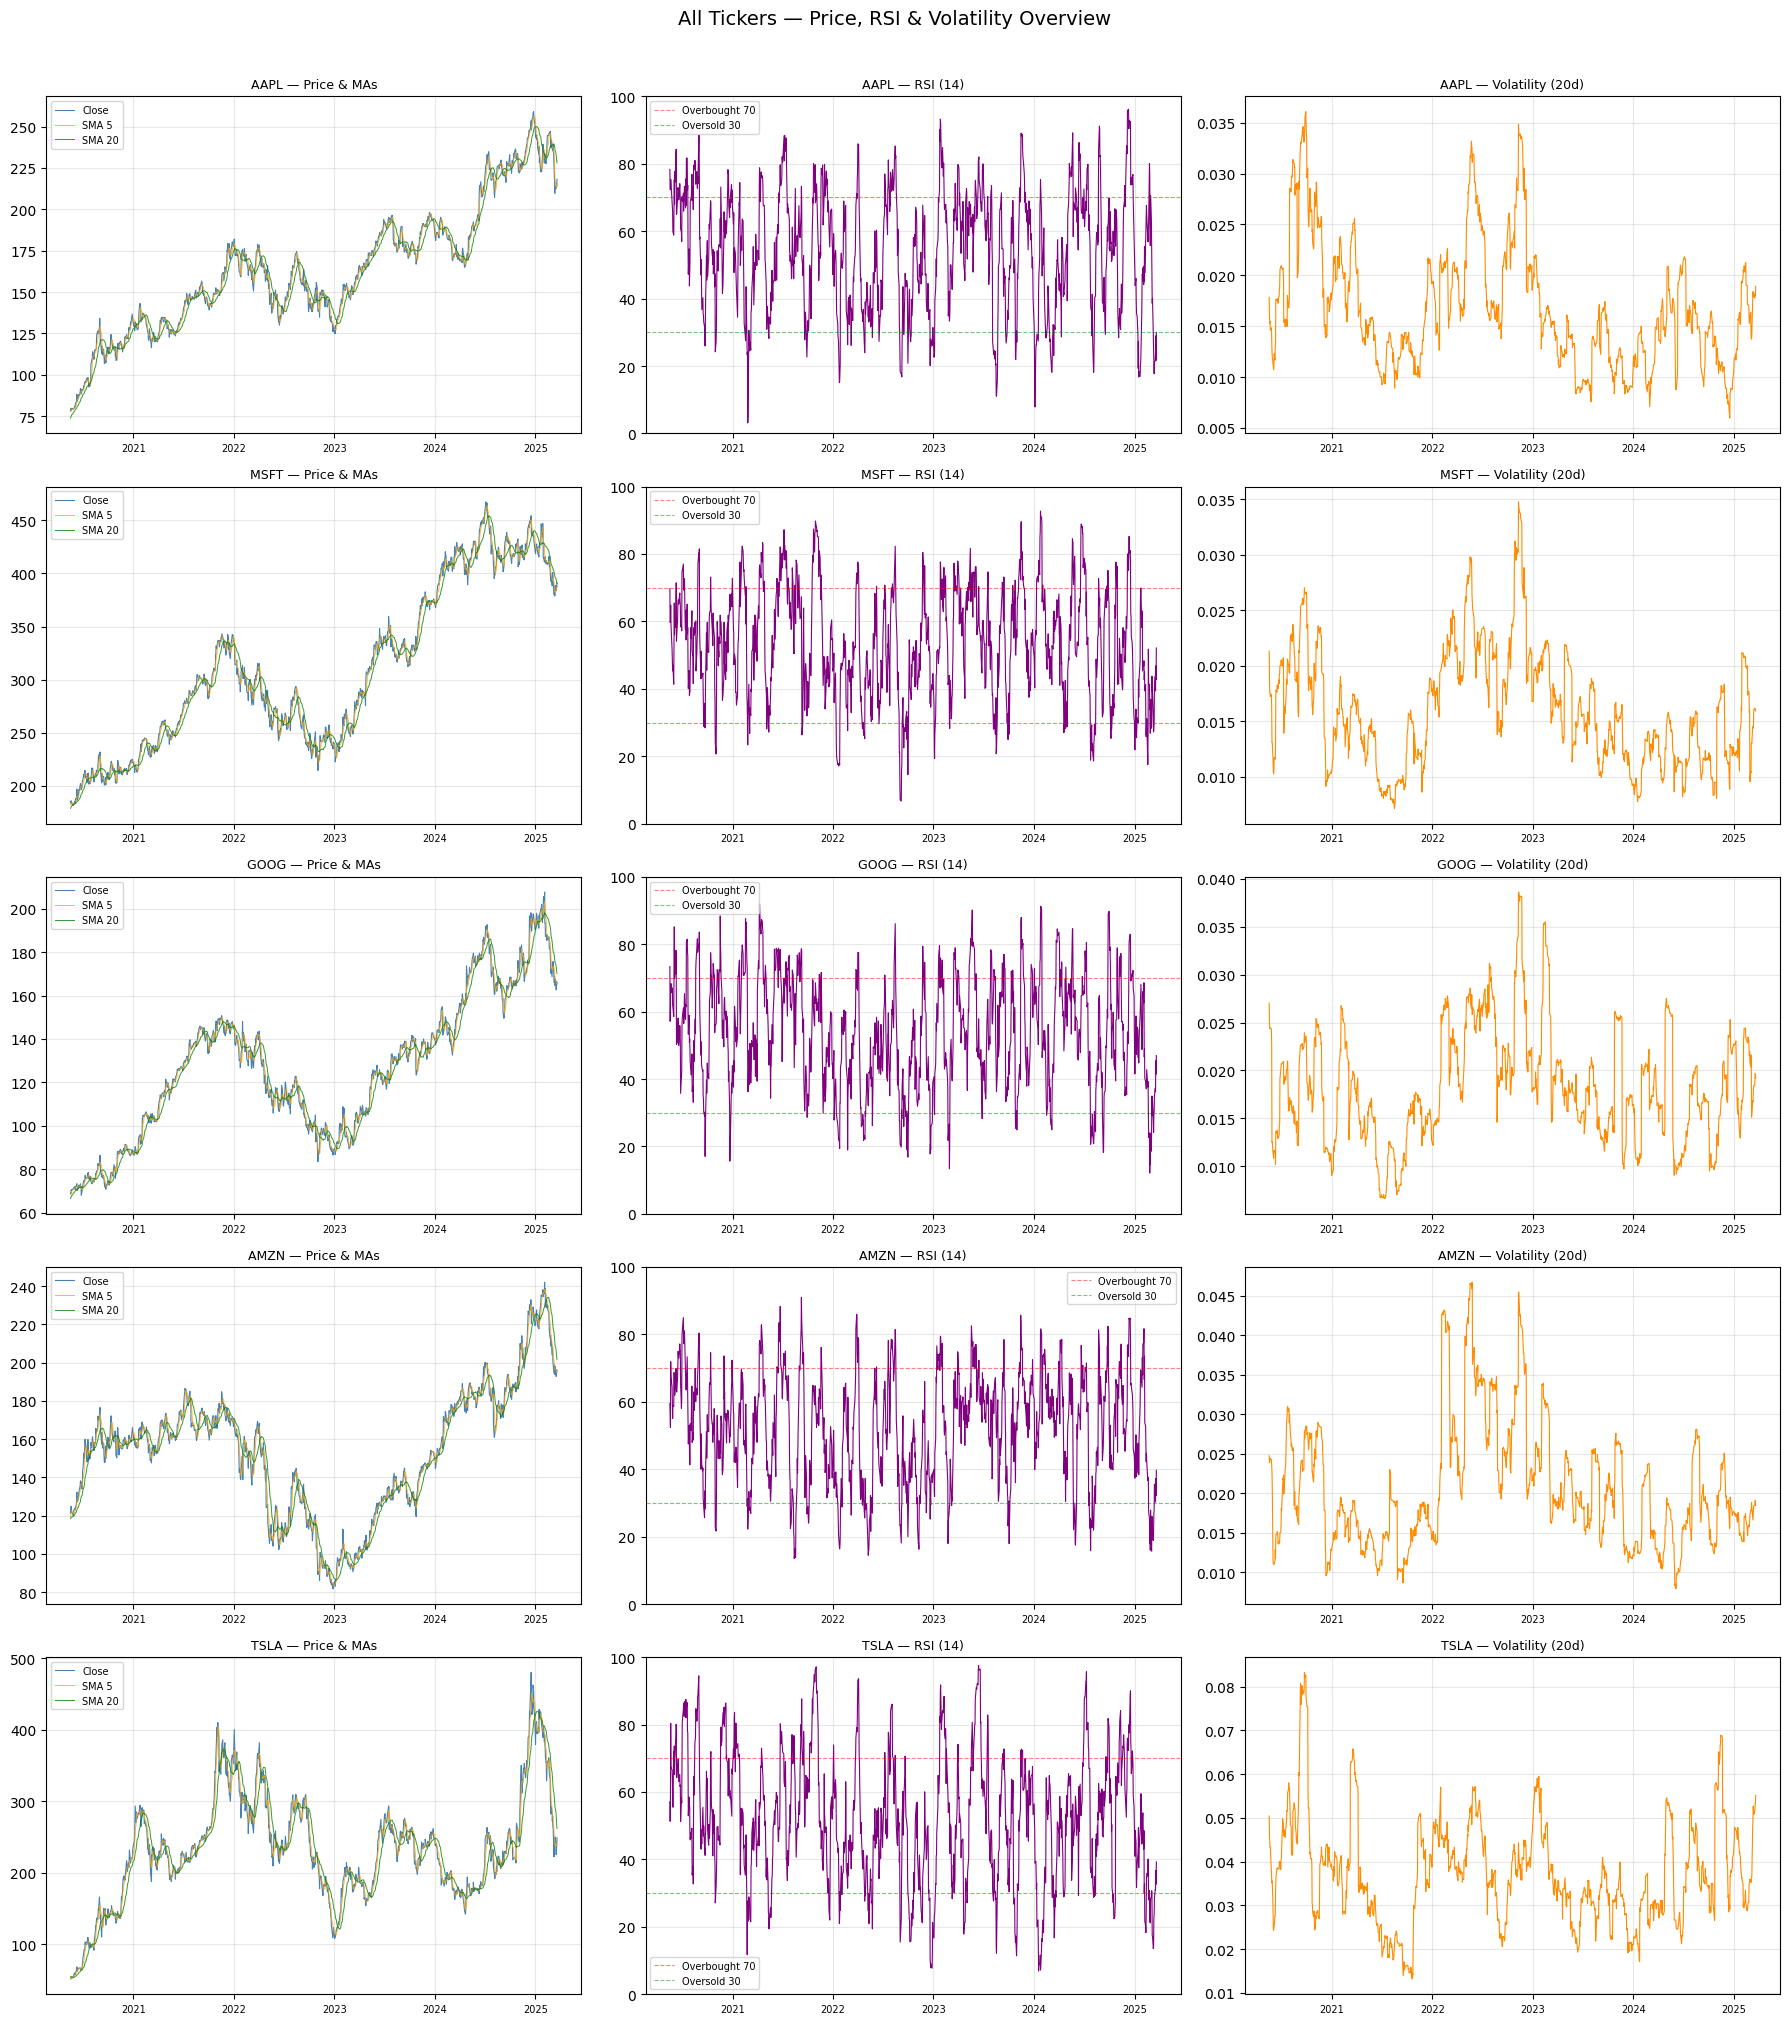

Chart saved to data/processed/all_tickers_overview.png


In [13]:
fig, axes = plt.subplots(len(TICKERS), 3, figsize=(18, 4 * len(TICKERS)))
fig.suptitle('All Tickers — Price, RSI & Volatility Overview', fontsize=14, y=1.01)

for i, t in enumerate(TICKERS):
    path = os.path.join(PROCESSED_DIR, f'{t}_processed.csv')
    if not os.path.exists(path):
        print(f'WARNING: {path} not found. Run section 3.7 first.')
        continue

    df_t = pd.read_csv(path, parse_dates=['Date'])

    # Close price + moving averages
    axes[i, 0].plot(df_t['Date'], df_t['Close'],  linewidth=0.8, label='Close',  color='steelblue')
    axes[i, 0].plot(df_t['Date'], df_t['SMA_5'],  linewidth=0.7, label='SMA 5',  color='orange',  alpha=0.8)
    axes[i, 0].plot(df_t['Date'], df_t['SMA_20'], linewidth=0.7, label='SMA 20', color='green',   alpha=0.8)
    axes[i, 0].set_title(f'{t} — Price & MAs', fontsize=9)
    axes[i, 0].legend(fontsize=7)
    axes[i, 0].grid(True, alpha=0.3)
    axes[i, 0].tick_params(axis='x', labelsize=7)

    # RSI
    axes[i, 1].plot(df_t['Date'], df_t['RSI_14'], linewidth=0.8, color='purple')
    axes[i, 1].axhline(70, color='red',   linestyle='--', alpha=0.5, linewidth=0.8, label='Overbought 70')
    axes[i, 1].axhline(30, color='green', linestyle='--', alpha=0.5, linewidth=0.8, label='Oversold 30')
    axes[i, 1].set_title(f'{t} — RSI (14)', fontsize=9)
    axes[i, 1].set_ylim(0, 100)
    axes[i, 1].legend(fontsize=7)
    axes[i, 1].grid(True, alpha=0.3)
    axes[i, 1].tick_params(axis='x', labelsize=7)

    # Volatility
    axes[i, 2].plot(df_t['Date'], df_t['Volatility_20'], linewidth=0.8, color='darkorange')
    axes[i, 2].set_title(f'{t} — Volatility (20d)', fontsize=9)
    axes[i, 2].grid(True, alpha=0.3)
    axes[i, 2].tick_params(axis='x', labelsize=7)

plt.tight_layout()

# Save for reuse in the Executive Summary
chart_path = os.path.join(PROCESSED_DIR, 'all_tickers_overview.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to {chart_path}')

---

## 4. Machine Learning Model

We use **Logistic Regression** for binary classification (UP/DOWN).

**Why Logistic Regression?**
- Simple and interpretable
- Works well as a baseline for binary classification
- Fast to train
- Outputs probabilities (confidence)

### 4.1 Prepare Data

In [14]:
# Separate features (X) and target (y)
X = df[FEATURE_COLUMNS].copy()
y = df['Target'].copy()

# Replace infinities
X = X.replace([np.inf, -np.inf], np.nan)
mask = X.notna().all(axis=1)
X = X[mask]
y = y[mask]

# shuffle=False because this is time-series data — we train on past, test on future
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'Training set: {len(X_train):,} rows')
print(f'Test set:     {len(X_test):,} rows')
print(f'Target balance (train): {dict(y_train.value_counts())}')

Training set: 974 rows
Test set:     244 rows
Target balance (train): {1: 504, 0: 470}


In [15]:
# StandardScaler transforms features to mean=0, std=1 — required for Logistic Regression
# Fit only on training data to avoid data leakage into the test set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features scaled!')
print(f'Example (before): {X_train.iloc[0].values[:3]}')
print(f'Example (after):  {X_train_scaled[0][:3]}')

Features scaled!
Example (before): [2.35278825e-02 7.75640000e+01 7.38290000e+01]
Example (after):  [ 1.22052357 -2.68844647 -2.75721567]


### 4.2 Train the Model

In [16]:
model = LogisticRegression(
    max_iter=1000,          # Max iterations for solver to converge
    random_state=42,        # Seed for reproducibility
    class_weight='balanced' # Handle class imbalance between UP and DOWN days
)
model.fit(X_train_scaled, y_train)

print('Model trained!')

Model trained!


### 4.3 Evaluate the Model

In [17]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)')

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['DOWN (0)', 'UP (1)']))

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(f'                 Predicted DOWN  Predicted UP')
print(f'  Actual DOWN    {cm[0][0]:>13}  {cm[0][1]:>12}')
print(f'  Actual UP      {cm[1][0]:>13}  {cm[1][1]:>12}')

Accuracy: 0.4180 (41.8%)

Classification Report:
              precision    recall  f1-score   support

    DOWN (0)       0.42      1.00      0.59       102
      UP (1)       0.00      0.00      0.00       142

    accuracy                           0.42       244
   macro avg       0.21      0.50      0.29       244
weighted avg       0.17      0.42      0.25       244

Confusion Matrix:
                 Predicted DOWN  Predicted UP
  Actual DOWN              102             0
  Actual UP                142             0


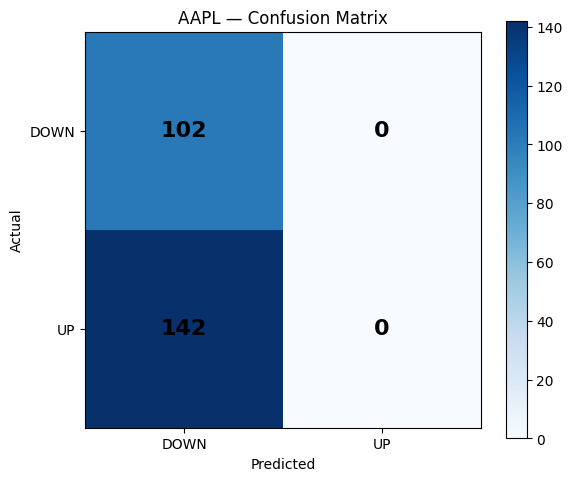

In [18]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['DOWN', 'UP'])
ax.set_yticklabels(['DOWN', 'UP'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('AAPL — Confusion Matrix')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i][j]), ha='center', va='center', fontsize=16, fontweight='bold')

plt.colorbar(im)
plt.tight_layout()
plt.show()

### 4.4 Feature Importance

Which features contribute most to the model's predictions?

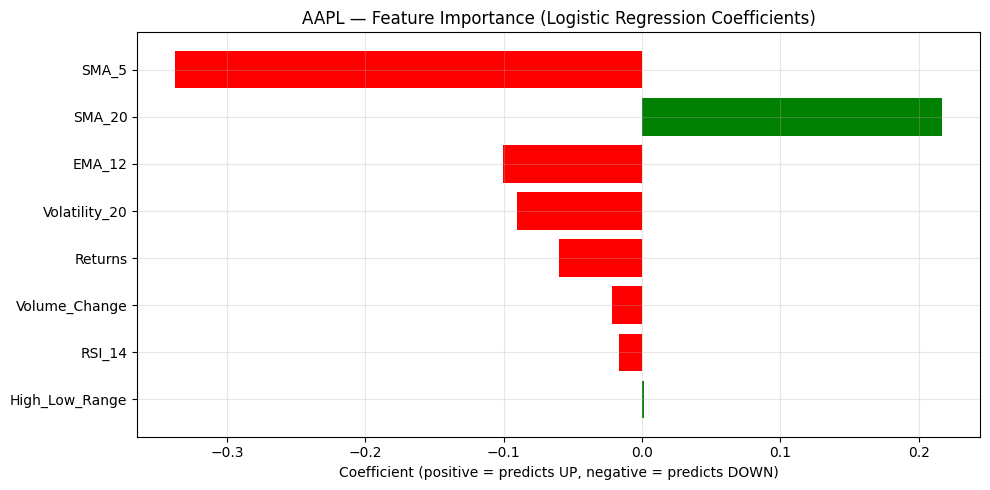

In [19]:
importance = pd.DataFrame({
    'Feature':     FEATURE_COLUMNS,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in importance['Coefficient']]
ax.barh(importance['Feature'], importance['Coefficient'], color=colors)
ax.set_xlabel('Coefficient (positive = predicts UP, negative = predicts DOWN)')
ax.set_title('AAPL — Feature Importance (Logistic Regression Coefficients)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Export Model

We save both the model and the scaler as `.pkl` files.
The web app needs **both** — the scaler to normalize live data, then the model to predict.

In [ ]:
os.makedirs(MODELS_DIR, exist_ok=True)

# Export model and scaler for ALL 5 tickers, not just AAPL.
# The Streamlit web app loads these .pkl files for every ticker it supports.
for t in TICKERS:
    processed_path = os.path.join(PROCESSED_DIR, f'{t}_processed.csv')
    if not os.path.exists(processed_path):
        print(f'{t}: processed CSV not found — run section 3.7 first. Skipping.')
        continue

    df_t = pd.read_csv(processed_path)

    X_t = df_t[FEATURE_COLUMNS].replace([np.inf, -np.inf], np.nan)
    y_t = df_t['Target']
    mask_t = X_t.notna().all(axis=1)
    X_t, y_t = X_t[mask_t], y_t[mask_t]

    X_tr, X_te, y_tr, y_te = train_test_split(X_t, y_t, test_size=0.2, shuffle=False)

    scaler_t = StandardScaler()
    X_tr_s = scaler_t.fit_transform(X_tr)

    model_t = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
    model_t.fit(X_tr_s, y_tr)

    joblib.dump(model_t,  os.path.join(MODELS_DIR, f'{t}_model.pkl'))
    joblib.dump(scaler_t, os.path.join(MODELS_DIR, f'{t}_scaler.pkl'))
    print(f'{t}: model and scaler saved to {MODELS_DIR}/')

print('\nAll models exported.')

---

## 5. Summary

| Step | Description |
|---|---|
| **Extract** | Loaded share price data from SimFin bulk CSV |
| **Transform** | Cleaned data, filled missing values, created 8 technical indicators |
| **Target** | Binary classification: UP (1) or DOWN (0) based on next day's close |
| **ETL — All tickers** | `transform()` applied to all 5 tickers, processed CSVs saved to `data/processed/` |
| **Model** | Logistic Regression with StandardScaler, 80/20 time-series split |
| **Export** | Model + scaler saved as `.pkl` files to `models/` for the Streamlit web app |

**Note:** Stock prediction accuracy around 50% is expected — the goal of this project is Python engineering, not prediction quality.

The final scripts (`src/etl.py` and `src/model.py`) automate this entire process for all 5 tickers.